# 37 — Vision Transformer CIFAR-10 experiment

This notebook turns the ViT data flow from [Notebook 36](./36_vision_transformer_intuition.ipynb) into a small trainable image classifier. We use the same balanced CIFAR-10 subsets and $16\times16$ inputs as [the earlier CNN experiment](./22_cnn_cifar10_experiment.ipynb) so that the comparison is understandable.

## Goals

- train a compact ViT-like classifier on CIFAR-10;
- inspect shapes, parameter count, learning curves, and predictions;
- compare training speed and accuracy with [Notebook 22's CNN](./22_cnn_cifar10_experiment.ipynb);
- understand common ViT mistakes and why CNNs often work better with limited image data.

This is an experiment rather than another low-level implementation exercise. PyTorch supplies optimized training and automatic differentiation; the model structure remains explicit.

In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10

from cs231n_practice.classifiers.vision_transformer import TinyVisionTransformer

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CLASS_NAMES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Recreate the controlled CIFAR-10 subsets

We deliberately reuse [Notebook 22's](./22_cnn_cifar10_experiment.ipynb) split: 100 training and 25 validation images per class from the official training set, plus 50 test images per class. The test set remains separate. Images are average-pooled to $16\times16$, scaled to $[0,1]$, and normalized with training-set channel statistics only.

> If CIFAR-10 is already under `data/`, this cell uses the local copy. Otherwise, `download=True` downloads it once.

In [3]:
train_dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
test_dataset = CIFAR10(root=DATA_DIR, train=False, download=True)
train_targets = np.asarray(train_dataset.targets, dtype=np.int64)
test_targets = np.asarray(test_dataset.targets, dtype=np.int64)
split_generator = np.random.default_rng(SEED)

training_parts, validation_parts = [], []
for class_index in range(10):
    indices = np.flatnonzero(train_targets == class_index)
    indices = split_generator.permutation(indices)[:125]
    training_parts.append(indices[:100])
    validation_parts.append(indices[100:125])
training_indices = split_generator.permutation(np.concatenate(training_parts))
validation_indices = split_generator.permutation(np.concatenate(validation_parts))

test_parts = []
for class_index in range(10):
    indices = np.flatnonzero(test_targets == class_index)
    test_parts.append(split_generator.permutation(indices)[:50])
test_indices = split_generator.permutation(np.concatenate(test_parts))

raw_train = train_dataset.data[training_indices]
raw_validation = train_dataset.data[validation_indices]
raw_test = test_dataset.data[test_indices]
y_train = train_targets[training_indices]
y_validation = train_targets[validation_indices]
y_test = test_targets[test_indices]

assert raw_train.shape == (1_000, 32, 32, 3)
assert np.array_equal(np.bincount(y_train), np.full(10, 100))
assert np.array_equal(np.bincount(y_validation), np.full(10, 25))
assert np.array_equal(np.bincount(y_test), np.full(10, 50))
print("Train / validation / test:", len(y_train), len(y_validation), len(y_test))

Train / validation / test: 1000 250 500


In [4]:
def downsample_to_nchw(images):
    """Average non-overlapping 2x2 blocks and return float32 NCHW data."""
    images = images.astype(np.float32) / 255.0
    images = images.reshape(-1, 16, 2, 16, 2, 3).mean(axis=(2, 4))
    return images.transpose(0, 3, 1, 2)

X_train = downsample_to_nchw(raw_train)
X_validation = downsample_to_nchw(raw_validation)
X_test = downsample_to_nchw(raw_test)
channel_mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
channel_std = X_train.std(axis=(0, 2, 3), keepdims=True)
X_train = (X_train - channel_mean) / channel_std
X_validation = (X_validation - channel_mean) / channel_std
X_test = (X_test - channel_mean) / channel_std

def tensor_dataset(images, labels):
    return TensorDataset(torch.from_numpy(images), torch.from_numpy(labels))

train_data = tensor_dataset(X_train, y_train)
validation_data = tensor_dataset(X_validation, y_validation)
test_data = tensor_dataset(X_test, y_test)
assert X_train.shape == (1_000, 3, 16, 16)
print("Model input shape:", X_train.shape)

Model input shape: (1000, 3, 16, 16)


## 2. Define a small ViT-like classifier

A convolution with kernel size equal to stride is an efficient learned patch projection. It does **not** behave like an ordinary overlapping CNN convolution: every input pixel belongs to exactly one patch. The class defaults to $4\times4$ patches, while the main experiment below uses the finer $2\times2$ patches that performed better in the initial comparison.

```text
(N, 3, 16, 16)
  -> patch projection -> (N, 32, 8, 8)
  -> flatten grid      -> (N, 64, 32)
  -> prepend [CLS]     -> (N, 65, 32)
  -> encoder block     -> (N, 65, 32)
  -> classify [CLS]    -> (N, 10)
```

We use learned positional embeddings, one encoder layer, four heads, and no dropout. This is intentionally tiny—not a competitive ViT.

In [5]:
# The implementation lives in cs231n_practice/classifiers/vision_transformer.py.
# Constructing it here keeps the architecture and shape check visible.
model = TinyVisionTransformer().to(device)
with torch.no_grad():
    example_scores = model(torch.from_numpy(X_train[:3]).to(device))
parameter_count = sum(parameter.numel() for parameter in model.parameters())
assert example_scores.shape == (3, 10)
print(model)
print(f"Trainable parameters: {parameter_count:,}")

TinyVisionTransformer(
  (patch_projection): Conv2d(3, 32, kernel_size=(4, 4), stride=(4, 4))
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (final_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
  (classifier): Linear(in_features=32, out_features=10, bias=True)
)
Trainable parameters: 11,082


## 3. Training and evaluation helpers

AdamW is common for Transformers. Weight decay discourages unnecessarily large weights, while the optimizer adapts the update scale of individual parameters. We record epoch-level loss and accuracy so that training and generalization can be compared.

In [6]:
def evaluate(model, dataset, batch_size=128):
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in DataLoader(dataset, batch_size=batch_size):
            predictions = model(images.to(device)).argmax(dim=1).cpu()
            correct += int((predictions == labels).sum())
    return correct / len(dataset)

def train_model(model, train_dataset, validation_dataset, *, epochs,
                learning_rate=3e-3, batch_size=64, verbose_on_epoch=1):
    loader_generator = torch.Generator().manual_seed(SEED)
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                        generator=loader_generator)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate,
                                  weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss()
    history = {"loss": [], "train_accuracy": [], "validation_accuracy": []}
    start = perf_counter()
    for epoch in range(epochs):
        model.train()
        loss_sum = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            loss_sum += float(loss.detach()) * len(labels)
        history["loss"].append(loss_sum / len(train_dataset))
        history["train_accuracy"].append(evaluate(model, train_dataset))
        history["validation_accuracy"].append(evaluate(model, validation_dataset))
        if (epoch + 1) % verbose_on_epoch == 0:
            print(
                f"epoch {epoch + 1:02d}/{epochs}: "
                f"loss={history['loss'][-1]:.3f}, "
                f"train={history['train_accuracy'][-1]:.3f}, "
                f"validation={history['validation_accuracy'][-1]:.3f}"
            )
    return history, perf_counter() - start

## 4. Diagnostic: overfit a tiny subset

Before the main experiment, confirm that the pipeline can memorize 20 examples. Failure here usually indicates a shape, label, optimizer, or model-capacity problem—not insufficient generalization.

In [7]:
torch.manual_seed(SEED + 1)
tiny_model = TinyVisionTransformer().to(device)
tiny_subset = TensorDataset(
    torch.from_numpy(X_train[:20]), torch.from_numpy(y_train[:20])
)
tiny_history, _ = train_model(
    tiny_model, tiny_subset, tiny_subset, epochs=20,
    learning_rate=5e-3, batch_size=20,
)
tiny_accuracy = evaluate(tiny_model, tiny_subset)
print(f"Tiny-subset accuracy: {tiny_accuracy:.3f}")
assert tiny_history["loss"][-1] < tiny_history["loss"][0]
assert tiny_accuracy >= 0.90

epoch 01/20: loss=2.376, train=0.350, validation=0.350
epoch 02/20: loss=1.826, train=0.650, validation=0.650
epoch 03/20: loss=1.500, train=0.600, validation=0.600
epoch 04/20: loss=1.291, train=0.800, validation=0.800
epoch 05/20: loss=1.096, train=0.900, validation=0.900
epoch 06/20: loss=0.899, train=0.950, validation=0.950
epoch 07/20: loss=0.762, train=1.000, validation=1.000
epoch 08/20: loss=0.635, train=1.000, validation=1.000
epoch 09/20: loss=0.528, train=1.000, validation=1.000
epoch 10/20: loss=0.443, train=1.000, validation=1.000
epoch 11/20: loss=0.368, train=1.000, validation=1.000
epoch 12/20: loss=0.311, train=1.000, validation=1.000
epoch 13/20: loss=0.264, train=1.000, validation=1.000
epoch 14/20: loss=0.222, train=1.000, validation=1.000
epoch 15/20: loss=0.188, train=1.000, validation=1.000
epoch 16/20: loss=0.161, train=1.000, validation=1.000
epoch 17/20: loss=0.138, train=1.000, validation=1.000
epoch 18/20: loss=0.117, train=1.000, validation=1.000
epoch 19/2

## 5. Train the fixed ViT configuration

The main run uses all 1,000 balanced training examples and $2\times2$ patches. Forty epochs equal about 640 minibatch updates. With such a small dataset, expect a noticeable training–validation gap and substantial run-to-run variation.

In [8]:
torch.manual_seed(SEED + 10)
model = TinyVisionTransformer(patch_size=2).to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
history, training_seconds = train_model(
    model, train_data, validation_data, epochs=40,
    learning_rate=3e-3, batch_size=64, verbose_on_epoch=5
)
print(f"Training time: {training_seconds:.1f} seconds")

epoch 05/40: loss=1.841, train=0.347, validation=0.252
epoch 10/40: loss=1.532, train=0.480, validation=0.312
epoch 15/40: loss=1.290, train=0.566, validation=0.260
epoch 20/40: loss=1.025, train=0.601, validation=0.276
epoch 25/40: loss=0.818, train=0.767, validation=0.280
epoch 30/40: loss=0.659, train=0.776, validation=0.264
epoch 35/40: loss=0.606, train=0.823, validation=0.272
epoch 40/40: loss=0.366, train=0.913, validation=0.276
Training time: 8.0 seconds


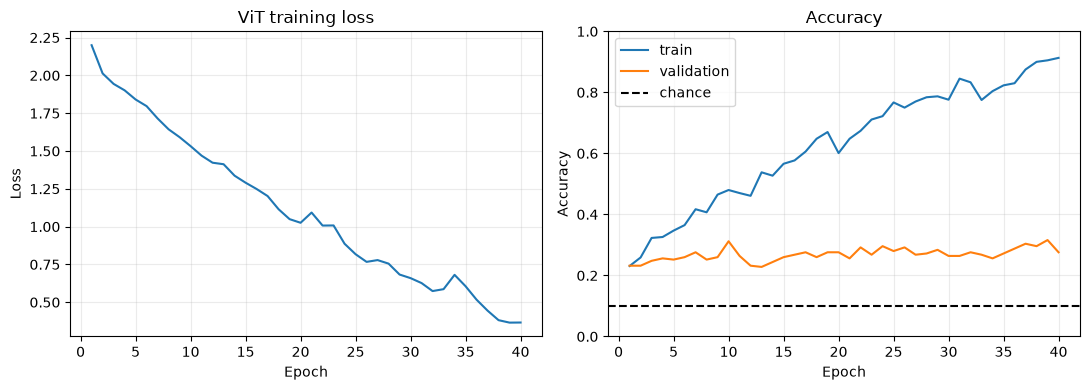

In [9]:
epochs = np.arange(1, len(history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, history["loss"])
axes[0].set(title="ViT training loss", xlabel="Epoch", ylabel="Loss")
axes[1].plot(epochs, history["train_accuracy"], label="train")
axes[1].plot(epochs, history["validation_accuracy"], label="validation")
axes[1].axhline(0.1, color="black", linestyle="--", label="chance")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
for axis in axes:
    axis.grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Compare with the earlier CNN

[Notebook 22](./22_cnn_cifar10_experiment.ipynb) recorded CNN accuracies of 0.560 training, 0.352 validation, and 0.390 test on these same split sizes and image resolution. Exact wall-clock times are not directly comparable: that CNN used educational NumPy loops, whereas this ViT uses optimized PyTorch operations. Parameter count and accuracy remain useful architectural observations, but this is not a rigorous benchmark.

     train: ViT=0.913  CNN=0.560
validation: ViT=0.276  CNN=0.352
      test: ViT=0.298  CNN=0.390
ViT generalization gap: 0.637
ViT parameters: 11,466


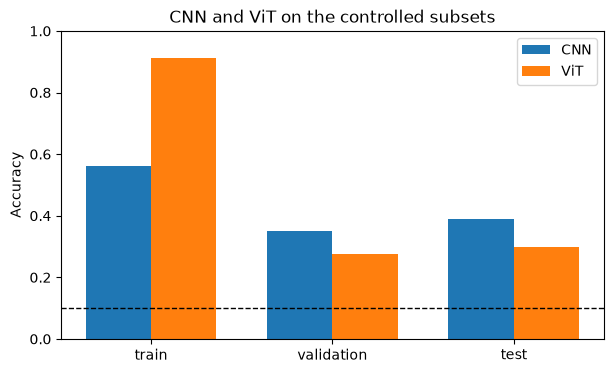

In [10]:
vit_results = {
    "train": evaluate(model, train_data),
    "validation": evaluate(model, validation_data),
    "test": evaluate(model, test_data),
}
cnn_results = {"train": 0.560, "validation": 0.352, "test": 0.390}
for split in vit_results:
    print(f"{split:>10}: ViT={vit_results[split]:.3f}  CNN={cnn_results[split]:.3f}")
print(f"ViT generalization gap: {vit_results['train'] - vit_results['validation']:.3f}")
print(f"ViT parameters: {parameter_count:,}")

positions = np.arange(3)
width = 0.36
fig, axis = plt.subplots(figsize=(7, 4))
axis.bar(positions - width / 2, list(cnn_results.values()), width, label="CNN")
axis.bar(positions + width / 2, list(vit_results.values()), width, label="ViT")
axis.axhline(0.1, color="black", linestyle="--", linewidth=1)
axis.set(xticks=positions, xticklabels=list(vit_results), ylabel="Accuracy",
         title="CNN and ViT on the controlled subsets", ylim=(0, 1))
axis.legend()
plt.show()

## 7. Inspect predictions and mistakes

Aggregate accuracy hides which images are easy or difficult. The following sample includes both correct and incorrect predictions when available.

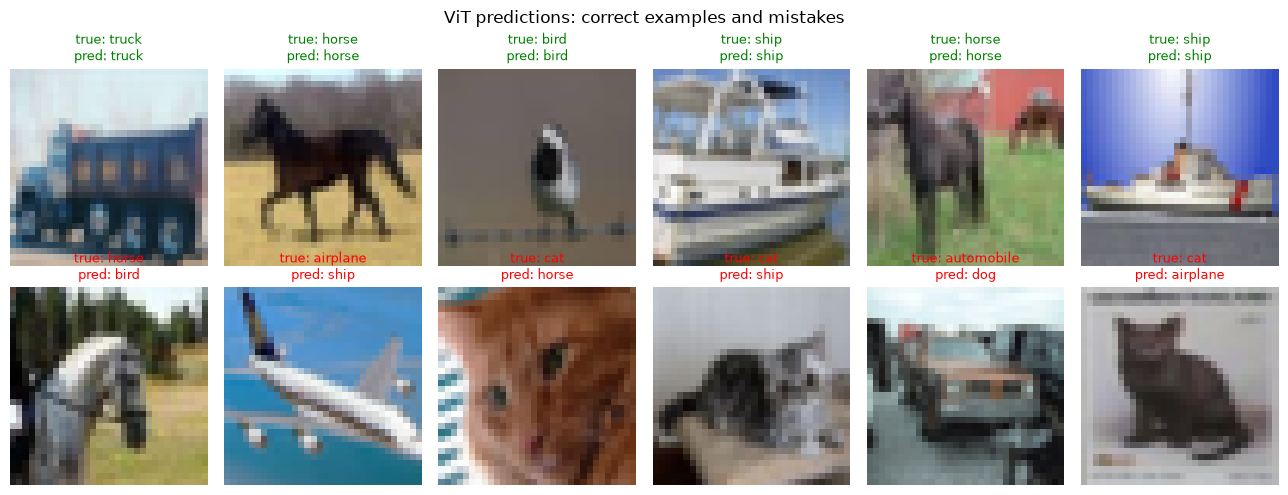

In [11]:
model.eval()
with torch.no_grad():
    test_predictions = model(torch.from_numpy(X_test).to(device)).argmax(1).cpu().numpy()
correct_indices = np.flatnonzero(test_predictions == y_test)[:6]
mistake_indices = np.flatnonzero(test_predictions != y_test)[:6]
display_indices = np.concatenate((correct_indices, mistake_indices))

fig, axes = plt.subplots(2, 6, figsize=(13, 5))
for index, axis in zip(display_indices, axes.ravel()):
    axis.imshow(raw_test[index])
    true_name = CLASS_NAMES[y_test[index]]
    predicted_name = CLASS_NAMES[test_predictions[index]]
    color = "green" if y_test[index] == test_predictions[index] else "red"
    axis.set_title(f"true: {true_name}\npred: {predicted_name}", color=color, fontsize=9)
    axis.axis("off")
plt.suptitle("ViT predictions: correct examples and mistakes")
plt.tight_layout()
plt.show()

## 8. Why a CNN may win with limited data

A CNN begins with useful assumptions about images: nearby pixels interact, the same filter is reused everywhere, and spatial locality is preserved throughout the feature hierarchy. These **inductive biases** reduce what the model must discover from examples.

Our ViT knows that tokens have positions, but it must learn more of the useful visual structure from data. With only 1,000 training images, that is difficult. Large ViTs can perform extremely well when trained with much more data, augmentation, regularization, or pretraining.

Common mistakes in a ViT pipeline include:

- forgetting to add positional information;
- mixing up NCHW and NHWC layouts;
- flattening the patch grid in an unintended order;
- using a patch size that does not divide the image dimensions;
- forgetting to expand `[CLS]` across the batch;
- interpreting random or untrained attention maps as explanations;
- comparing models trained with different splits or preprocessing as if the comparison were controlled.

## Reflection

Answer briefly after running the experiment.

1. Did the tiny-subset diagnostic succeed, and what does that establish?
2. How did the ViT's training, validation, and test accuracies compare?
3. How did its validation and test accuracy compare with the earlier CNN?
4. What does the train–validation gap suggest?
5. Why is wall-clock time here not a fair architectural comparison?
6. What useful image assumptions does a CNN contain that this ViT must learn?
7. What happens to sequence length and attention cost if patch size is reduced from 4 to 2?
8. What would you change before drawing strong conclusions about CNNs versus ViTs?

### Answers

1. Yes. The model reached 100% accuracy on the 20-image subset, showing that the model, loss, optimizer, and data pipeline can fit a tiny sample. It does not establish that the model generalizes.
2. Training accuracy reached 0.913, while validation accuracy ended at 0.276 and test accuracy was 0.298. Validation accuracy peaked earlier and then stopped improving while training accuracy continued to rise.
3. The CNN performed better on this small dataset: 0.352 versus 0.276 validation accuracy and 0.390 versus 0.298 test accuracy.
4. The large gap of 0.637 indicates substantial overfitting: the ViT fits the training subset much better than it generalizes to unseen images.
5. The CNN used educational NumPy loops, whereas the ViT uses optimized PyTorch operations. Runtime also depends on implementation, hardware, batch size, and optimizer, so it does not isolate the effect of architecture.
6. A CNN assumes spatial locality and reuses the same filters across image locations. These assumptions make nearby visual patterns and translation-related structure easier to learn from limited data.
7. The number of patch tokens increases from 16 to 64, so the complete sequence grows from 17 to 65 tokens. Each attention matrix grows from $17^2=289$ to $65^2=4225$ entries—about 14.6 times as many, not merely four times as many.
8. I would use more training data, stronger augmentation and regularization, avoid downsampling when resources allow, tune both models comparably, and repeat the experiment with several random seeds before drawing a strong conclusion.